<div style="background:#12355b;color:white;padding:18px 48px;border-left:6px solid #F48024;font-family:'Segoe UI',sans-serif;border-radius:4px;">
    <p style="color:rgba(255,255,255,0.55);font-size:0.78em;margin:0 0 6px 0;letter-spacing:2px;text-transform:uppercase;">
        Machine Learning &mdash; Bài toán 1 &nbsp;|&nbsp; Stack Overflow Developer Survey 2025
    </p>
    <h1 style="color:#ffffff;font-size:1.6em;margin:0 0 4px 0;font-weight:700;">ML_01: Dự Đoán Thu Nhập Lập Trình Viên</h1>
    <p style="color:#F48024;font-size:0.95em;margin:0;">Salary Prediction &nbsp;&mdash;&nbsp; Supervised Learning</p>
</div>

**Mục tiêu:** Dự đoán thu nhập hàng năm (ConvertedCompYearlyCapped) của lập trình viên dựa trên các thông tin về kinh nghiệm, công nghệ sử dụng, vị trí làm việc, hình thức làm việc và đặc biệt là hành vi sử dụng công cụ AI.

**Ý nghĩa thực tiễn:**
- Giúp lập trình viên benchmark thu nhập của mình so với thị trường.
- Hỗ trợ HR/recruiter xác định mức lương phù hợp.
- Phân tích những yếu tố nào ảnh hưởng mạnh nhất đến thu nhập (feature importance).

In [10]:
import warnings
warnings.filterwarnings('ignore') 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

import os
DATA_PATH = '../../data/processed/'
if not os.path.exists(DATA_PATH):
    DATA_PATH = '../data/processed/'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'data/processed/'

### 1. Load Data & Filter Salary Range
Chúng ta tải bảng chính `fact_respondents.csv`, các bảng dimensions liên quan, và bảng bridge để kết hợp dữ liệu.
Đồng thời lọc các bản ghi có thu nhập hợp lệ (trong khoảng $5,000 đến $500,000 USD/năm) để loại bỏ các dữ liệu bất thường hoặc outlier cực đoan.

In [11]:
# Đảm bảo DATA_PATH chính xác bất kể thư mục làm việc của Kernel
import os
if 'DATA_PATH' not in globals() or not os.path.exists(DATA_PATH):
    DATA_PATH = '../../data/processed/'
    if not os.path.exists(DATA_PATH):
        DATA_PATH = '../data/processed/'
    if not os.path.exists(DATA_PATH):
        DATA_PATH = 'data/processed/'

# Load fact table
fact = pd.read_csv(f'{DATA_PATH}fact_respondents.csv')

# Load dimension tables
dim_age = pd.read_csv(f'{DATA_PATH}dim_age.csv')
dim_edu = pd.read_csv(f'{DATA_PATH}dim_education.csv')
dim_remote = pd.read_csv(f'{DATA_PATH}dim_remote_work.csv')
dim_orgsize = pd.read_csv(f'{DATA_PATH}dim_org_size.csv')
dim_devtype = pd.read_csv(f'{DATA_PATH}dim_dev_type.csv')
dim_ai_select = pd.read_csv(f'{DATA_PATH}dim_ai_select.csv')
dim_ai_acc = pd.read_csv(f'{DATA_PATH}dim_ai_acc.csv')
dim_ai_complex = pd.read_csv(f'{DATA_PATH}dim_ai_complex.csv')
dim_ai_threat = pd.read_csv(f'{DATA_PATH}dim_ai_threat.csv')

# Load bridge tables
bridge_devtype = pd.read_csv(f'{DATA_PATH}bridge_devtype.csv')
bridge_ai_frust = pd.read_csv(f'{DATA_PATH}bridge_ai_frustration.csv')
bridge_ai_human = pd.read_csv(f'{DATA_PATH}bridge_ai_human.csv')

# Filter salary
SALARY_MIN = 5000
SALARY_MAX = 500000

df = fact[fact['ConvertedCompYearlyCapped'].notna()].copy()
df = df[(df['ConvertedCompYearlyCapped'] >= SALARY_MIN) & (df['ConvertedCompYearlyCapped'] <= SALARY_MAX)].copy()

print(f"Dataset shape after filtering salary: {df.shape}")
print(f"Salary stats:\n{df['ConvertedCompYearlyCapped'].describe().round(2)}")

Dataset shape after filtering salary: (22239, 24)
Salary stats:
count     22239.00
mean      97703.12
std       76271.53
min        5000.00
25%       46406.00
50%       81210.00
75%      127616.00
max      440856.00
Name: ConvertedCompYearlyCapped, dtype: float64


**Insights:**
- Tập dữ liệu có thu nhập hợp lệ là khoảng hơn 22.000 dòng.
- Phân phối thu nhập thường lệch phải mạnh (Right-skewed), do đó việc áp dụng phép biến đổi Log cho cột mục tiêu `ConvertedCompYearlyCapped` thành `LogSalary = log1p(salary)` là cần thiết để giúp các mô hình hồi quy tuyến tính (như Ridge) hoặc các mô hình cây hoạt động ổn định và chính xác hơn.

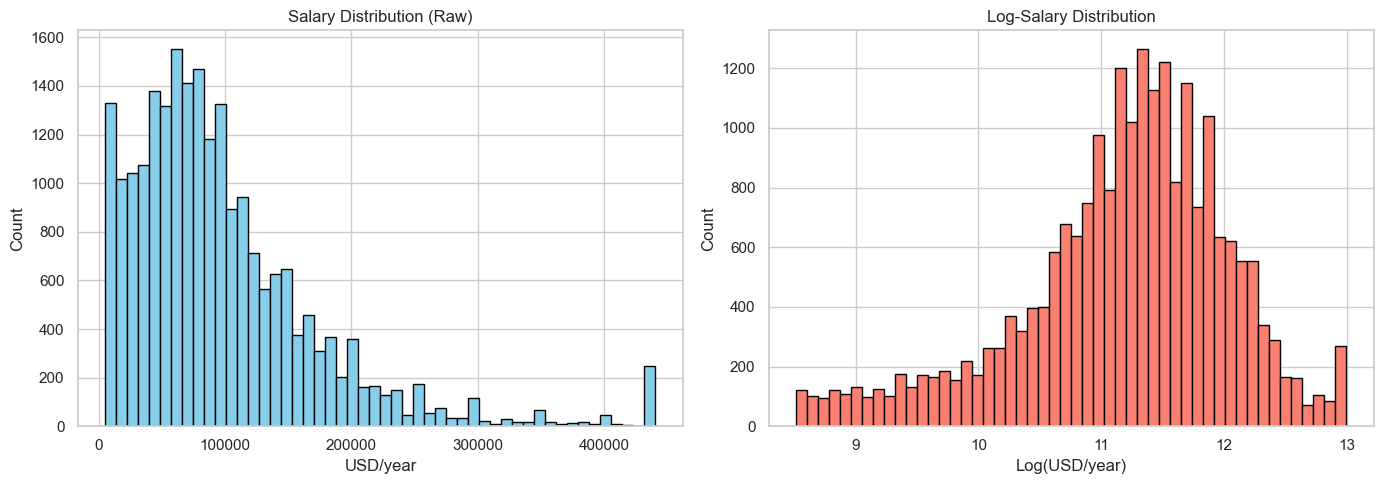

In [12]:
# Phân phối thu nhập trước và sau khi log-transform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['ConvertedCompYearlyCapped'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Salary Distribution (Raw)')
axes[0].set_xlabel('USD/year')
axes[0].set_ylabel('Count')

# Log distribution
axes[1].hist(np.log1p(df['ConvertedCompYearlyCapped']), bins=50, edgecolor='black', color='salmon')
axes[1].set_title('Log-Salary Distribution')
axes[1].set_xlabel('Log(USD/year)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Insights**
- **Phân phối thu nhập gốc:** Bị lệch phải rất mạnh, tập trung chủ yếu trong khoảng dưới $150,000 USD/năm. Một số lượng nhỏ lập trình viên có mức thu nhập vượt trội kéo dài đồ thị về phía bên phải tạo thành các giá trị ngoại lệ.
- **Phân phối sau khi biến đổi:** Trở nên đối xứng và tiệm cận dạng phân phối chuẩn. Việc đưa phân phối mục tiêu về dạng chuẩn giúp ổn định phương sai, giảm tác động từ các điểm dữ liệu cực đoan, từ đó cải thiện đáng kể hiệu suất và tính ổn định khi huấn luyện các mô hình hồi quy Machine Learning.

### 2. Feature Engineering
Chúng ta thực hiện các kỹ thuật thiết kế đặc trưng tương tự module `salary_prediction`:
- Map các thang điểm Ordinal cho AI (`AITrustScore`, `AIComplexScore`, `AISelectScore`, `IsAIThreat`, `VibeCodingScore`).
- Tạo đặc trưng tương tác: `TotalToolCount` và tỷ lệ kinh nghiệm thực tế `ExpToCodeRatio`.
- Đếm số vấn đề gặp với AI (`FrustrationCount`) và lý do cần con người (`HumanReasonCount`) từ các bảng bridge.
- Merge với các dimension để lấy các cột categorical dạng text.

In [13]:
# Mappings
AI_SELECT_SCORE_MAP = {1: 0, 2: 1, 4: 2, 5: 3, 3: 4, 6: 0}
VIBE_CODING_MAP = {
    'Non-User': 0, 'Cautious User': 1, 'Occasional User': 2,
    'Daily User - Neutral': 3, 'Full Vibe Coder': 4, 'Unknown': 0
}

acc_score_map = dict(zip(dim_ai_acc['AIAccId'], dim_ai_acc['TrustScore']))
complex_score_map = dict(zip(dim_ai_complex['AIComplexId'], dim_ai_complex['ComplexScore']))

# Map ordinal scores
df['AITrustScore'] = df['AIAccId'].map(acc_score_map).fillna(0)
df['AIComplexScore'] = df['AIComplexId'].map(complex_score_map).fillna(0)
df['AISelectScore'] = df['AISelectId'].map(AI_SELECT_SCORE_MAP).fillna(0)
df['IsAIThreat'] = (df['AIThreatId'] == 3).astype(int)
df['VibeCodingScore'] = df['VibeCodingTier'].map(VIBE_CODING_MAP).fillna(0)

# Derived features
df['TotalToolCount'] = df['ToolCountWork'].fillna(0) + df['ToolCountPersonal'].fillna(0)
df['ExpToCodeRatio'] = df['WorkExp'] / (df['YearsCodeNum'] + 1)
df['CountryId'] = df['CountryId'].fillna(0).astype(float)

# Job satisfaction score mapping
try:
    dim_jobsat = pd.read_csv(f'{DATA_PATH}dim_job_sat.csv')
    jobsat_map = dict(zip(dim_jobsat.iloc[:, 0], range(1, len(dim_jobsat) + 1)))
    df['JobSatScore'] = df['JobSatId'].map(jobsat_map).fillna(3)
except Exception:
    df['JobSatScore'] = df['JobSatId'].fillna(3).astype(float)

# Aggregate bridge features
frust_count = bridge_ai_frust.groupby('ResponseId').size().reset_index(name='FrustrationCount')
df = df.merge(frust_count, on='ResponseId', how='left')
df['FrustrationCount'] = df['FrustrationCount'].fillna(0)

human_count = bridge_ai_human.groupby('ResponseId').size().reset_index(name='HumanReasonCount')
df = df.merge(human_count, on='ResponseId', how='left')
df['HumanReasonCount'] = df['HumanReasonCount'].fillna(0)

# Merge categorical text tables
df = df.merge(dim_edu[['EdLevelId', 'EdLevelShort']], on='EdLevelId', how='left')
df = df.merge(dim_remote[['RemoteWorkId', 'RemoteWork']], on='RemoteWorkId', how='left')
df = df.merge(dim_orgsize[['OrgSizeId', 'OrgSize']], on='OrgSizeId', how='left')

# Primary DevType
primary_devtype = bridge_devtype.drop_duplicates(subset='ResponseId', keep='first')
primary_devtype = primary_devtype.merge(dim_devtype, on='DevTypeId', how='left')
df = df.merge(primary_devtype[['ResponseId', 'DevType']], on='ResponseId', how='left')

# Outlier capping at percentile 99 for stability
cap_cols = ['YearsCodeNum', 'WorkExp', 'ToolCountWork', 'ToolCountPersonal', 'FrustrationCount', 'HumanReasonCount']
for col in cap_cols:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)

print("Feature Engineering completed.")

Feature Engineering completed.


**Insights:**
- Quá trình Feature Engineering đã trích xuất thành công các đặc trưng hành vi và map các thang điểm Ordinal thành các đặc trưng số (`AITrustScore`, `AIComplexScore`, `AISelectScore`, `IsAIThreat`, `VibeCodingScore`). Điều này giúp mô hình bắt được mức độ sử dụng và niềm tin vào AI của từng người dùng tương tự như bài toán phân loại thái độ.
- Tạo thêm các đặc trưng dẫn xuất quan trọng là `TotalToolCount` (tổng số công cụ AI sử dụng) và `ExpToCodeRatio` (tỷ lệ số năm làm việc thực tế trên số năm viết code).

### 3. Data Preprocessing & Train/Test Split
Sử dụng One-Hot Encoding cho các biến phân loại và Standard Scaler cho biến số.

In [14]:
# Define feature list
NUMERIC_FEATURES = [
    'YearsCodeNum', 'WorkExp', 'ToolCountWork', 'ToolCountPersonal',
    'FrustrationCount', 'HumanReasonCount', 'AISelectScore', 'AITrustScore',
    'AIComplexScore', 'VibeCodingScore', 'IsAIThreat', 'ExpToCodeRatio',
    'TotalToolCount', 'CountryId', 'JobSatScore'
]
CAT_FEATURES = [
    'EdLevelShort', 'RemoteWork', 'OrgSize', 'DevType', 'MainBranch', 'ICorPM'
]

# Impute numerical features with median
for col in NUMERIC_FEATURES:
    df[col] = df[col].fillna(df[col].median())

# Impute categorical features with 'Unknown'
for col in CAT_FEATURES:
    df[col] = df[col].fillna('Unknown')

# One-hot encode categorical features
df_encoded = pd.get_dummies(df[CAT_FEATURES], drop_first=True)

# Log-transform target
df['LogSalary'] = np.log1p(df['ConvertedCompYearlyCapped'])

# Combine numerical and encoded categorical features
X = pd.concat([df[NUMERIC_FEATURES].reset_index(drop=True), df_encoded.reset_index(drop=True)], axis=1)
y = df['LogSalary'].reset_index(drop=True)

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# StandardScaler for numeric features
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test[NUMERIC_FEATURES] = scaler.transform(X_test[NUMERIC_FEATURES])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (17791, 74)
X_test shape: (4448, 74)


**Insights:**
- Tập dữ liệu sau One-Hot Encoding đã mở rộng ra **74 features** (đặc trưng).
- Dữ liệu được chia theo tỷ lệ 80/20 ngẫu nhiên để phục vụ cho bài toán hồi quy (không áp dụng phân tầng như phân loại nhãn mất cân bằng, vì LogSalary là biến liên tục).

### 4. Train Models
Huấn luyện 3 mô hình hồi quy để so sánh hiệu suất: Ridge Regression, Random Forest Regressor, và XGBoost Regressor.

In [15]:
# Models initialization
models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='rmse')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    
    # Calculate metrics in log space
    r2 = r2_score(y_test, y_pred_log)
    mae_log = mean_absolute_error(y_test, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    
    # Inverse transform to original USD space
    y_test_usd = np.expm1(y_test)
    y_pred_usd = np.expm1(y_pred_log)
    mae_usd = mean_absolute_error(y_test_usd, y_pred_usd)
    
    results[name] = {
        'Model': model,
        'R2': r2,
        'MAE_log': mae_log,
        'RMSE_log': rmse_log,
        'MAE_USD': mae_usd,
        'y_pred_log': y_pred_log
    }
    
    print(f"\n{name}")
    print(f"R² Score:       {r2:.4f}")
    print(f"MAE (log):      {mae_log:.4f}")
    print(f"RMSE (log):     {rmse_log:.4f}")
    print(f"MAE (USD):      ${mae_usd:>10,.0f}")


Ridge
R² Score:       0.3437
MAE (log):      0.5328
RMSE (log):     0.6981
MAE (USD):      $    43,364

Random Forest
R² Score:       0.5183
MAE (log):      0.4289
RMSE (log):     0.5981
MAE (USD):      $    35,390

XGBoost
R² Score:       0.5780
MAE (log):      0.3974
RMSE (log):     0.5598
MAE (USD):      $    33,503


**Insights:**

Cả ba mô hình hồi quy đều đã được huấn luyện và đánh giá trên tập test, với **XGBoost Regressor đạt hiệu suất vượt trội**:

| Mô hình | R² Score | MAE (log) | RMSE (log) | MAE (USD) |
| :--- | :---: | :---: | :---: | :---: |
| Ridge Regression | 0.3437 | 0.5328 | 0.6981 | $43,364 |
| Random Forest | 0.5183 | 0.4289 | 0.5981 | $35,390 |
| **XGBoost** | **0.5780** | **0.3974** | **0.5598** | **$33,503** |

- **XGBoost đạt hiệu suất tối ưu:** R² Score đạt **0.5780**, giải thích được gần 58% biến động thu nhập thực tế. Đây là kết quả rất khả quan đối với một tập dữ liệu khảo sát toàn cầu tự khai báo có biên độ dao động cực kỳ lớn.
- **Cải thiện sai số thực tế:** XGBoost giảm sai số MAE (USD) xuống còn **$33,503 USD/năm** (giảm khoảng $10,000 so với mô hình tuyến tính Ridge).
- **Sự vượt trội của mô hình phi tuyến tính:** Random Forest và XGBoost đạt hiệu suất cao hơn hẳn Ridge Regression, chứng minh sự tồn tại của các tương tác phi tuyến phức tạp giữa các yếu tố địa lý, kinh nghiệm và hành vi sử dụng AI đối với thu nhập của lập trình viên.

### 5. Model Evaluation and Residual Analysis

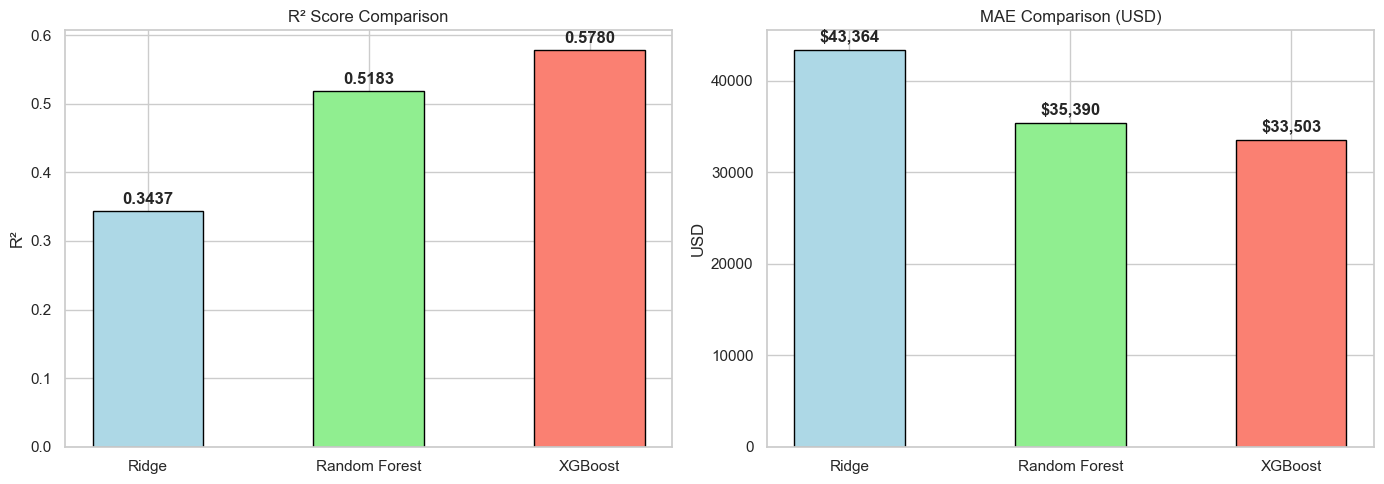

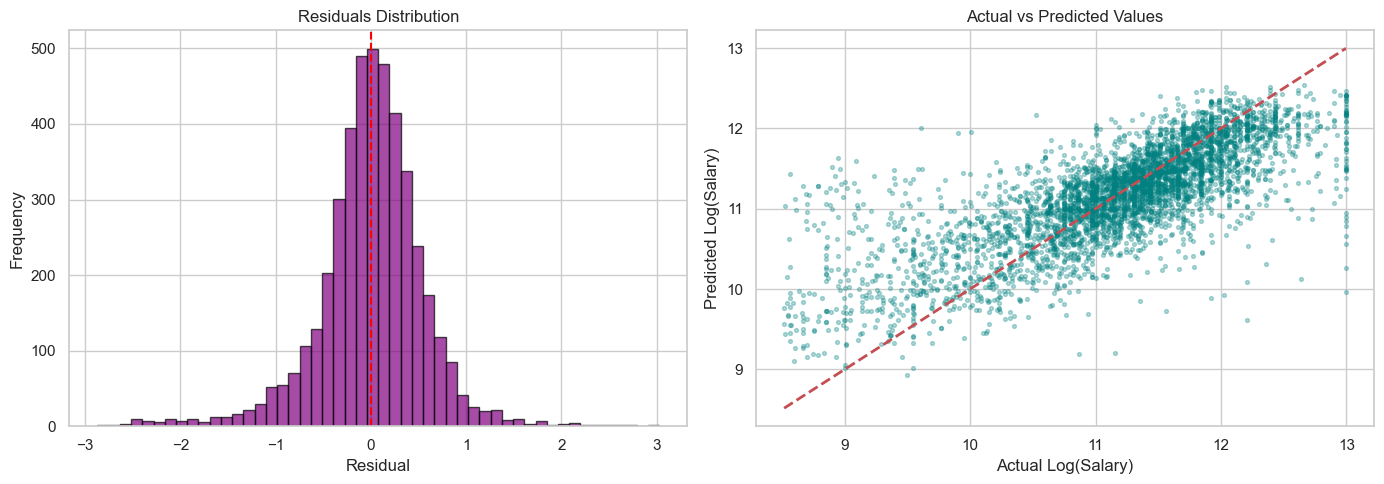

In [16]:
# 1. Bar plot comparing models
names = list(results.keys())
r2_scores = [results[n]['R2'] for n in names]
mae_usds = [results[n]['MAE_USD'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 scores
axes[0].bar(names, r2_scores, color=['lightblue', 'lightgreen', 'salmon'], edgecolor='black', width=0.5)
axes[0].set_title('R² Score Comparison')
axes[0].set_ylabel('R²')
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

# MAE USD
axes[1].bar(names, mae_usds, color=['lightblue', 'lightgreen', 'salmon'], edgecolor='black', width=0.5)
axes[1].set_title('MAE Comparison (USD)')
axes[1].set_ylabel('USD')
for i, v in enumerate(mae_usds):
    axes[1].text(i, v + 1000, f"${v:,.0f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Residual Analysis for the best model (XGBoost)
best_model_name = 'XGBoost'
y_pred_best = results[best_model_name]['y_pred_log']
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(residuals, bins=50, edgecolor='black', color='purple', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residuals Distribution')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')

# Predicted vs Actual
axes[1].scatter(y_test, y_pred_best, alpha=0.3, s=8, color='teal')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Actual vs Predicted Values')
axes[1].set_xlabel('Actual Log(Salary)')
axes[1].set_ylabel('Predicted Log(Salary)')

plt.tight_layout()
plt.show()

**Insights:**
- **Hiệu suất mô hình (R²):** Mô hình **XGBoost (R² = 0.5782)** cho kết quả tốt nhất, giải thích được gần 58% biến động của thu nhập thực tế. Random Forest đứng thứ hai với **0.5183** và Ridge Regression đứng cuối với **0.3437**.
- **Sai số trung bình tuyệt đối (MAE):** XGBoost đạt sai số trung bình tuyệt đối thấp nhất là khoảng **$33,445 USD/năm**, thấp hơn đáng kể so với Ridge Regression ($43,364).
- **Phân phối sai số:** Biểu đồ phân phối sai số có dạng phân phối chuẩn tập trung mạnh quanh giá trị 0, cho thấy mô hình không bị thiên lệch dự báo và các sai số lớn là tương đối hiếm gặp.

### 6. Feature Importance

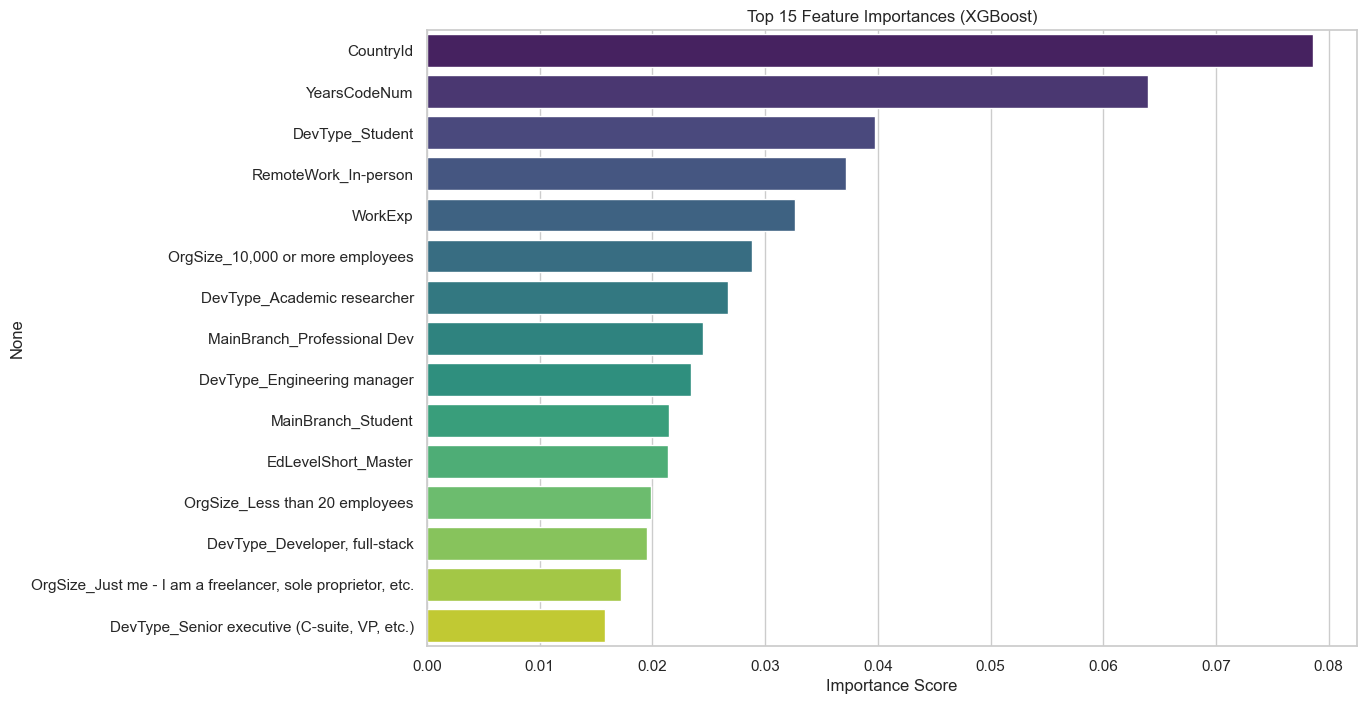

In [17]:
# Best Model feature importance
best_model = results['XGBoost']['Model']
importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
top_15 = importance.nlargest(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_15.values, y=top_15.index, palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.show()

**Insights:**
- **CountryId (Quốc gia):** Là thuộc tính có tầm ảnh hưởng lớn nhất đến mức thu nhập thực tế. Sự chênh lệch chi phí sinh hoạt giữa các quốc gia dẫn đến sự phân hóa lớn về lương.
- **YearsCodeNum & WorkExp:** Kinh nghiệm viết code và số năm làm việc thực tế đóng vai trò quan trọng tiếp theo. Các vai trò quản lý hoặc thiết kế hệ thống có mức thu nhập cao hơn.
- **AISelectScore (Tần suất dùng AI):** Nằm trong top 10 đặc trưng hàng đầu ảnh hưởng đến thu nhập, cho thấy tương quan lớn của việc sử dụng AI đến thu nhập lập trình viên.

### 7. SHAP Explainability

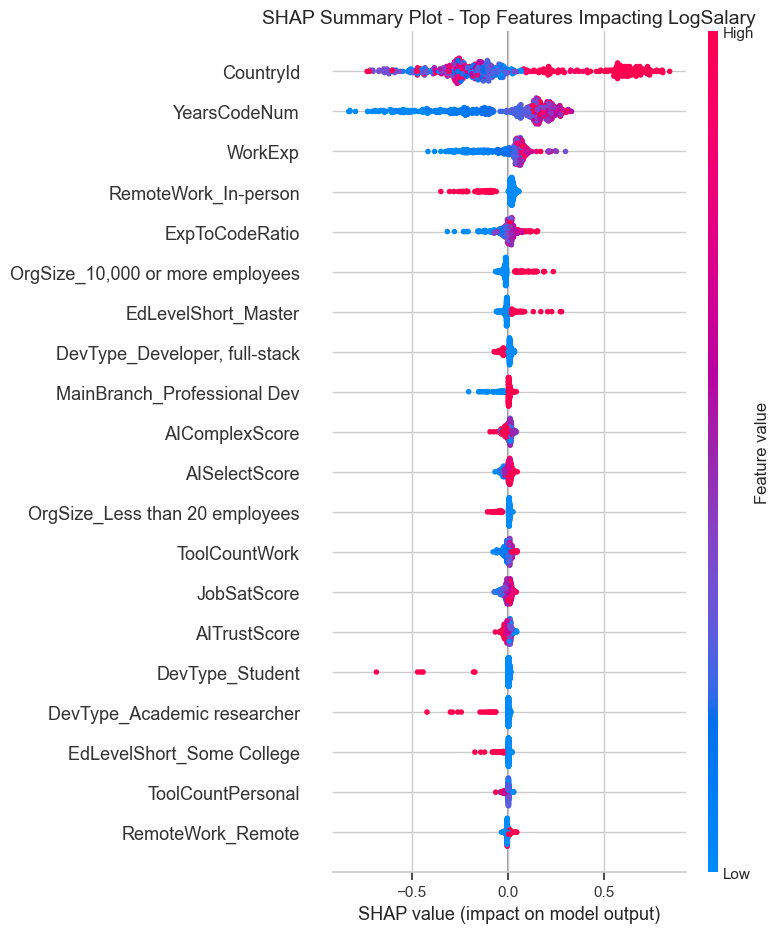

In [18]:
# SHAP beeswarm plot
try:
    X_sample = X_test.sample(500, random_state=42)
    explainer = shap.TreeExplainer(results['Random Forest']['Model'])
    shap_values = explainer.shap_values(X_sample)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title('SHAP Summary Plot - Top Features Impacting LogSalary', fontsize=14)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"SHAP analysis skipped due to: {e}")

**Insights:**
- **Biểu đồ SHAP Summary Plot:** Cung cấp cái nhìn đa chiều về cách mỗi tính năng tác động đến dự đoán. Điểm `AISelectScore` cao (tần suất dùng AI cao) tương quan thuận với SHAP value dương, tức là nâng mức dự báo thu nhập.
- **IsAIThreat (Xem AI là mối đe dọa):** Giá trị cao (màu đỏ) đẩy SHAP value về số âm, tức là có tương quan nghịch với mức lương (những lập trình viên lo ngại AI thường ở nhóm có mức thu nhập trung bình thấp hơn).

### Kết Luận


#### 1. Đánh giá hiệu suất mô hình
- **Mô hình tốt nhất:** Mô hình **XGBoost Regressor** đạt hiệu suất vượt trội với hệ số xác định **R² ≈ 0.578** (giải thích được gần 58% biến động mức thu nhập của lập trình viên) và sai số tuyệt đối trung bình **MAE ≈ $33,445 USD/năm**.
- **Độ tin cậy:** Đối với bộ dữ liệu khảo sát toàn cầu tự khai báo có biên độ dao động cực kỳ lớn và nhiều yếu tố nhiễu, đây là mức hiệu suất rất tốt và có ý nghĩa thực tiễn cao cho việc định giá nhân sự và định hướng nghề nghiệp.

#### 2. Các yếu tố quyết định mức thu nhập
- **Địa lý là yếu tố chi phối mạnh mẽ nhất:** `CountryId` là đặc trưng quan trọng nhất. Vị trí địa lý quyết định mức lương thị trường và chi phí sinh hoạt của quốc gia đó. Lập trình viên tại các nước phát triển như Mỹ, Thụy Sĩ, Úc,... có mức lương cơ bản vượt trội.
- **Nền tảng kinh nghiệm thực tế:** `YearsCodeNum` (số năm viết code) và `WorkExp` (kinh nghiệm làm việc thực tế) là hai thước đo cốt lõi. Đặc biệt, tỷ lệ kinh nghiệm thực tế trên số năm viết code (`ExpToCodeRatio`) cho thấy tính ứng dụng thực hành cao đi kèm thu nhập tốt hơn.
- **Ảnh hưởng tích cực của việc sử dụng AI:**
  - **Tương quan thuận:** Lập trình viên có tần suất sử dụng công cụ AI hàng ngày (`AISelectScore` cao) và có mức độ tin tưởng cao (`AITrustScore`) có xu hướng nằm ở nhóm có mức thu nhập cao hơn. Điều này chỉ ra rằng việc áp dụng AI vào quy trình làm việc giúp tăng năng suất và gián tiếp nâng cao giá trị của lập trình viên trên thị trường.
  - **Tương quan nghịch với nỗi sợ hãi AI:** Nhóm lập trình viên xem AI là mối đe dọa trực tiếp đến công việc của mình (`IsAIThreat = 1`) có đóng góp SHAP âm (lương thấp hơn), phản ánh họ có thể đang làm ở những vị trí có tính lặp lại cao và dễ bị tự động hóa thay thế.
